In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\src\ML\Session_9\Code\income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [3]:
X = df[['Age', 'Income($)']]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#5. Dunn Index Function

def dunn_index(X, labels):
    clusters = np.unique(labels)

    # Max intra-cluster distance
    intra_dists = []
    for c in clusters:
        points = X[labels == c]
        if len(points) > 1:
            intra_dists.append(np.max(cdist(points, points)))
        else:
            intra_dists.append(0)
    max_intra = np.max(intra_dists)

    # Min inter-cluster distance
    inter_dists = []
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            cluster_i = X[labels == clusters[i]]
            cluster_j = X[labels == clusters[j]]
            inter_dists.append(np.min(cdist(cluster_i, cluster_j)))
    min_inter = np.min(inter_dists)

    return min_inter / max_intra if max_intra != 0 else 0

In [6]:
k_values = range(2, 7)

inertia = []
silhouette = []
dunn = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    dunn.append(dunn_index(X_scaled, labels))

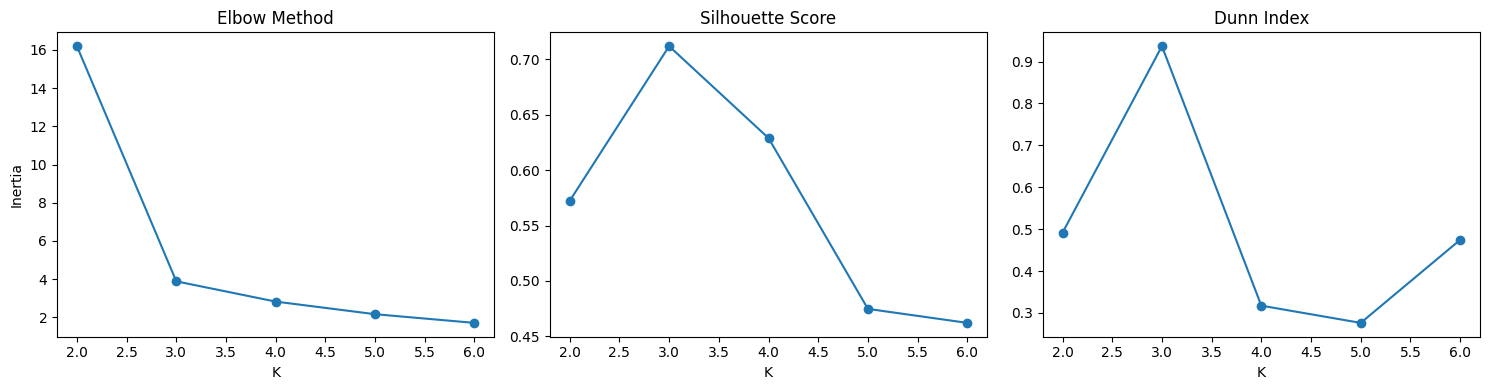

In [7]:
plt.figure(figsize=(15, 4))

# Elbow
plt.subplot(1, 3, 1)
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

# Silhouette
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")

# Dunn
plt.subplot(1, 3, 3)
plt.plot(k_values, dunn, marker='o')
plt.title("Dunn Index")
plt.xlabel("K")

plt.tight_layout()
plt.show()

In [8]:
best_k = k_values[np.argmax(silhouette)]
print("Best K (based on Silhouette):", best_k)

Best K (based on Silhouette): 3


In [9]:
final_model = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df['Cluster'] = final_model.fit_predict(X_scaled)

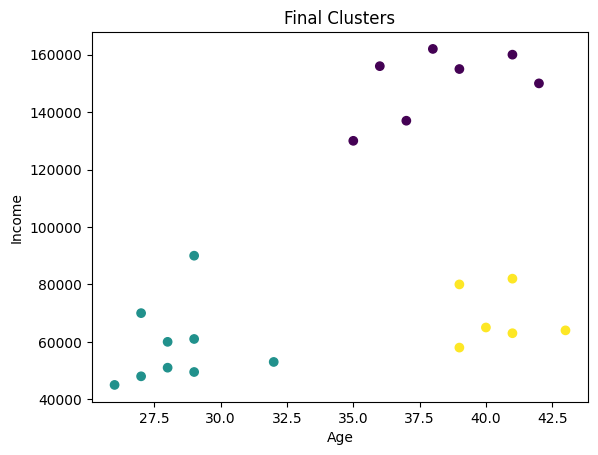

In [10]:
plt.figure()
plt.scatter(df['Age'], df['Income($)'], c=df['Cluster'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Final Clusters")
plt.show()



In [ ]:
df

,Name,Age,Income($),Cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0
5,Gautam,39,155000,0
6,David,41,160000,0
7,Andrea,38,162000,0
8,Brad,36,156000,0
9,Angelina,35,130000,0
